In [215]:
building = 0

# Setup

In [216]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import cvxpy as cp

import Project.src.data.dataprep as prep
import Project.src.tensors.tensorisation as tensor

from Project.src.models.lstm import LSTM
from Project.src.models.lstmopt import LSTMOPT
from Project.src.models.lstmopt import CVXLayer

from Project.src.training.training import  Training as Training
from Project.src.training.training_opt import Training as Training_opt

import Project.src.util.formulas as fm

from torch.nn import functional as F

def torch_py(torch_tensor):
    return torch_tensor.cpu().detach().numpy().flatten()

def rescale(values, scaler):
    rescaled_values = values * (scaler[1] - scaler[0]) + scaler[0]   
    return rescaled_values

In [217]:
nl_data = prep.dutch_data('../data/Dutchdata_clean/building_' + str(building) + '.parquet', 'h')
nl_data['net_load'] = nl_data['load'] - nl_data['solar_energy']
nl_price_data = pd.read_csv('../data/NL_DA_Prices.csv', index_col='Date',parse_dates=True, dayfirst=True)
nl_data = nl_data.merge(nl_price_data[['offtake', 'injection']], left_index=True, right_index=True)
nl_data['cost'] = nl_data.apply(lambda row: row['net_load'] * row['injection'] if row['net_load'] < 0 else row['net_load'] * row['offtake'], axis=1)

In [218]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Optimization problems

In [219]:
# Base parameters
battery_capacity = round(nl_data['solar_energy'].max() * 1.24,2)
max_charge = battery_capacity/2.7
max_discharge = max_charge
battery_penalty = 10e5
T = 24
epochs = 100

### Actual optimization problem

In [220]:
imp = cp.Variable(T)
exp = cp.Variable(T)
bat_energy = cp.Variable(T+1)
mode = cp.Variable(T)
bat_charge = cp.Variable(T)
bat_discharge = cp.Variable(T)
variables = [imp, exp, bat_energy, mode, bat_charge, bat_discharge]

load = cp.Parameter(T)
off = cp.Parameter(T)
inj = cp.Parameter(T)
pv = cp.Parameter(T)
initial_battery_energy = cp.Parameter()

parameters = [pv, load, off, inj, initial_battery_energy]

objective = cp.Minimize(cp.sum(imp @  off - exp @ inj))

constraints = [
    pv + imp + bat_discharge == exp + load + bat_charge,
    exp >= 0,
    exp <= pv + bat_discharge,
    imp >= 0,
    bat_charge >= 0,
    bat_discharge >= 0,
    bat_charge <= max_charge * (1-mode),
    bat_discharge <= max_discharge * mode,
    bat_energy[0] == initial_battery_energy,
    bat_energy[-1] == initial_battery_energy,
    bat_energy >= battery_capacity*0.2,
    bat_energy <= battery_capacity*0.8,
    mode >= 0,
    mode <= 1,
    ]

for t in range(1,T+1):
    constraints += [
        bat_energy[t] == bat_energy[t-1] + bat_charge[t-1] - bat_discharge[t-1],
    ]
    
problem = cp.Problem(objective, constraints)

### Optimization problem post forecasting

In [221]:
imp_fcst = cp.Variable(T)
exp_fcst = cp.Variable(T)
bat_energy_fcst = cp.Variable(T+1)
variables_fcst = [imp_fcst, exp_fcst, bat_energy_fcst]

load_fcst = cp.Parameter(T)
off_fcst = cp.Parameter(T)
inj_fcst = cp.Parameter(T)
pv_fcst = cp.Parameter(T)
initial_battery_energy_fcst = cp.Parameter()
bat_charge_fcst = cp.Parameter(T)
bat_discharge_fcst = cp.Parameter(T)

parameters_fcst = [pv_fcst, load_fcst, off_fcst, inj_fcst, initial_battery_energy_fcst, bat_charge_fcst, bat_discharge_fcst]

objective_fcst = cp.Minimize(cp.sum(imp_fcst @  off_fcst - exp_fcst @ inj_fcst))

constraints_fcst = [
    pv_fcst + imp_fcst + bat_discharge_fcst == exp_fcst + load_fcst + bat_charge_fcst,
    exp_fcst >= 0,
    exp_fcst <= pv_fcst + bat_discharge_fcst,
    imp_fcst >= 0,
    bat_energy_fcst[0] == initial_battery_energy_fcst,
    bat_energy_fcst[-1] == initial_battery_energy_fcst,
    bat_energy_fcst >= battery_capacity*0.05,
    bat_energy_fcst <= battery_capacity*0.95,
    ]

for t in range(1,T+1):
    constraints_fcst += [
        bat_energy_fcst[t] == bat_energy_fcst[t-1] + bat_charge_fcst[t-1] - bat_discharge_fcst[t-1]
    ]
    
problem_fcst = cp.Problem(objective_fcst, constraints_fcst)

# LSTM model

## Tensors

In [222]:
# Tensors for training
nl_tensors = tensor.Tensors(nl_data,'solar_energy',['solar_energy'],[],24,24)
X_train_base, X_test_base, y_train_base, y_test_base, scalers = nl_tensors.create_tensor()

## Model

In [223]:
lstm = LSTM(1,200,3,24,0.5).to(device)

In [224]:
trainer_base = Training(lstm, X_train_base, y_train_base, X_test_base, y_test_base, epochs)

Step 0: Average train loss: 0.0448 | Average test loss: 0.0407
Step 5: Average train loss: 0.0143 | Average test loss: 0.0159
Step 10: Average train loss: 0.0130 | Average test loss: 0.0144
Step 15: Average train loss: 0.0126 | Average test loss: 0.0140
Step 20: Average train loss: 0.0125 | Average test loss: 0.0134
Step 25: Average train loss: 0.0147 | Average test loss: 0.0152
Step 30: Average train loss: 0.0122 | Average test loss: 0.0131
Step 35: Average train loss: 0.0123 | Average test loss: 0.0138
Step 40: Average train loss: 0.0121 | Average test loss: 0.0137
Step 45: Average train loss: 0.0130 | Average test loss: 0.0131
Step 50: Average train loss: 0.0117 | Average test loss: 0.0144
Step 55: Average train loss: 0.0114 | Average test loss: 0.0129
Step 60: Average train loss: 0.0116 | Average test loss: 0.0135
Step 65: Average train loss: 0.0118 | Average test loss: 0.0153
Step 70: Average train loss: 0.0115 | Average test loss: 0.0143
Step 75: Average train loss: 0.0112 | Aver

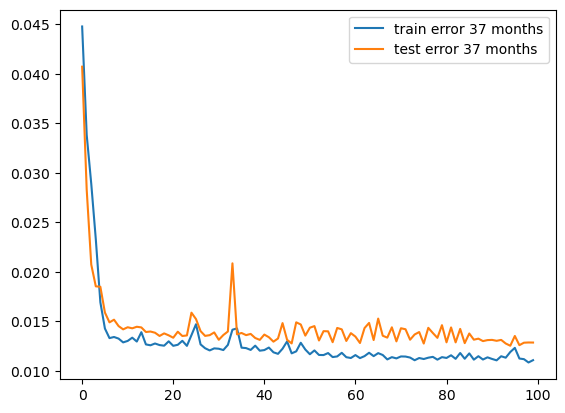

In [225]:
state_dicts_lstm, best_lstm = trainer_base.fit()

In [226]:
lstm.load_state_dict(state_dicts_lstm[best_lstm])

<All keys matched successfully>

# LSTM-CVX model

## Tensors

In [227]:
# Tensors for training
nl_opt_tensors = tensor.Tensors(nl_data,'solar_energy',['solar_energy'],['load','offtake','injection'],24,24, domain_min=[None, 0, 0, 0, None], domain_max=[None, 1, 1, 1, None])
X_train, X_test, _, _, scalers_opt = nl_opt_tensors.create_tensor()

nl_normal_tensors = tensor.Tensors(nl_data,'solar_energy',['solar_energy'],[],24,24)
_, _, y_train_pv, y_test_pv, scalers_normal = nl_normal_tensors.create_tensor()

In [228]:
initial_bat_tensor_train = torch.zeros([X_train.shape[0],24,1])
initial_bat_tensor_test = torch.zeros([X_test.shape[0],24,1])

initial_bat_tensor_train[:,-1,:] = battery_capacity * 0.5
initial_bat_tensor_test[:,-1,:] = battery_capacity * 0.5

X_train = torch.concat([X_train, initial_bat_tensor_train],dim=-1)
X_test = torch.concat([X_test, initial_bat_tensor_test],dim=-1)

In [229]:
cvx_real = CVXLayer(problem, parameters, variables)

In [230]:
cvx_vars_train = cvx_real(rescale(y_train_pv,scalers_normal[0]),
                          X_train[:,:,1],
                          X_train[:,:,2],
                          X_train[:,:,3],
                          X_train[:,-1,4])

cvx_vars_test = cvx_real(rescale(y_test_pv, scalers_normal[0]),
                         X_test[:,:,1],
                         X_test[:,:,2],
                         X_test[:,:,3],
                         X_test[:,-1,4])

In [231]:
solution_train = (torch.bmm(cvx_vars_train[0].unsqueeze(1), X_train[:,:,2].unsqueeze(-1)) -
                  torch.bmm(cvx_vars_train[1].unsqueeze(1), X_train[:,:,3].unsqueeze(-1)))

solution_test = (torch.bmm(cvx_vars_test[0].unsqueeze(1), X_test[:,:,2].unsqueeze(-1)) -
                 torch.bmm(cvx_vars_test[1].unsqueeze(1), X_test[:,:,3].unsqueeze(-1)))

In [232]:
y_train_solution = F.pad(solution_train,(0,0,0,23))
y_test_solution = F.pad(solution_test,(0,0,0,23))

In [233]:
y_train_pv = torch.cat([y_train_pv.unsqueeze(-1), y_train_solution], dim=-1)
y_test_pv = torch.cat([y_test_pv.unsqueeze(-1), y_test_solution], dim=-1)

## Model

In [234]:
lstm_opt = LSTMOPT(1,200,3,24,0.5,problem,parameters,variables,scalers_opt[0]).to(device)
lstm_opt_transfer = LSTMOPT(1,200,3,24,0.5,problem,parameters,variables,scalers_opt[0]).to(device)
cvx_fcst = CVXLayer(problem_fcst, parameters_fcst, variables_fcst)

In [235]:
trainer = Training_opt(lstm_opt, cvx_fcst, X_train, y_train_pv, X_test, y_test_pv, epochs, T, battery_capacity, min_beta=0.2, max_beta=0.8)
trainer_transfer = Training_opt(lstm_opt_transfer, cvx_fcst, X_train, y_train_pv, X_test, y_test_pv, epochs, T, battery_capacity, learning_rate=0.0001, min_beta=0.2, max_beta=0.8)

In [194]:
import torch
from torch import nn
from cvxpylayers.torch import CvxpyLayer
from torch.utils.data import DataLoader, TensorDataset

In [197]:
batch_size = 1
min_beta = 1
max_beta = 1

train_data = TensorDataset(X_train.to(device), y_train_pv.to(device))
test_data = TensorDataset(X_test.to(device), y_test_pv.to(device))
train_loader = DataLoader(train_data, batch_size=batch_size)
test_loader = DataLoader(test_data, batch_size=batch_size)

model = lstm_opt
cvx = CVXLayer(problem_fcst, parameters_fcst, variables_fcst)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
epochs = epochs
T = T
bat_cap = battery_capacity

In [198]:
num_train_batches = 0
num_test_batches = 0
total_loss = 0
total_mse = 0
total_regret = 0
total_loss_test = 0
total_mse_test = 0
total_regret_test = 0

model.train()
batches = iter(train_loader)
batch_nr = 1
for input, output in batches:
    print(f'currently working on batch {batch_nr}')
    pv_train, y_train = model(input[:, :, 0:-4],
                                   input[:, -T:, -4],
                                   input[:, -T:, -3],
                                   input[:, -T:, -2],
                                   input[:, -1, -1])
    
    y_train = cvx(output[:, :, 0],
                       input[:, -T:, -4],
                       input[:, -T:, -3],
                       input[:, -T:, -2],
                       input[:, -1, -1],
                       y_train[-2],
                       y_train[-1])

    prediction = (torch.bmm(y_train[0].unsqueeze(1), input[:, -T:, -3].unsqueeze(-1)) -
                  torch.bmm(y_train[1].unsqueeze(1), input[:, -T:, -2].unsqueeze(-1)))
    prediction = prediction.squeeze([1, 2])

    mse_loss = criterion(pv_train, output[:, :, 0])
    regret = criterion(prediction, output[:, 0, 1])
    
    loss = regret
    
    total_loss += float(loss)

    num_train_batches += 1
    batch_nr += 1
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

currently working on batch 1
currently working on batch 2
currently working on batch 3
currently working on batch 4
currently working on batch 5
currently working on batch 6
currently working on batch 7
currently working on batch 8
currently working on batch 9
currently working on batch 10
currently working on batch 11
currently working on batch 12
currently working on batch 13
currently working on batch 14
currently working on batch 15
currently working on batch 16
currently working on batch 17
currently working on batch 18
currently working on batch 19
currently working on batch 20
currently working on batch 21
currently working on batch 22
currently working on batch 23
currently working on batch 24
currently working on batch 25
currently working on batch 26
currently working on batch 27
currently working on batch 28
currently working on batch 29
currently working on batch 30
currently working on batch 31
currently working on batch 32
currently working on batch 33
currently working o

SolverError: Solver scs returned status infeasible

In [209]:
cvx(output[:, :, 0],input[:, -T:, -4],input[:, -T:, -3],input[:, -T:, -2],input[:, -1, -1],y_train[-2],y_train[-1])

Please consider re-formulating your problem so that it is always solvable or increasing the number of solver iterations.


SolverError: Solver scs returned status infeasible

In [214]:
max_charge

2.3851851851851853

In [213]:
input[:, -T:, -2]

tensor([[0.0280, 0.0280, 0.0270, 0.0250, 0.0250, 0.0260, 0.0320, 0.0350, 0.0370,
         0.0360, 0.0360, 0.0340, 0.0320, 0.0300, 0.0290, 0.0290, 0.0320, 0.0350,
         0.0410, 0.0430, 0.0420, 0.0410, 0.0390, 0.0370]], device='cuda:0')

Step 0:
Average train loss: 0.5115 | Average test loss: 0.6918

Step 0:
Average train regret: 0.5115 | Average test regret: 3.2129
Average train MSE: 0.0591 | Average test MSE: 0.0616

MSE: 0.80 | Regret: 0.20
Step 5:
Average train loss: 0.4739 | Average test loss: 0.6960
Step 10:
Average train loss: 0.5020 | Average test loss: 0.7279

Step 10:
Average train regret: 0.5020 | Average test regret: 3.3743
Average train MSE: 0.0620 | Average test MSE: 0.0662

MSE: 0.73 | Regret: 0.27
Step 15:
Average train loss: 0.6443 | Average test loss: 0.9378
Step 20:
Average train loss: 0.6670 | Average test loss: 1.1362

Step 20:
Average train regret: 0.6670 | Average test regret: 4.0584
Average train MSE: 0.0598 | Average test MSE: 0.0737

MSE: 0.67 | Regret: 0.33
Step 25:
Average train loss: 0.7538 | Average test loss: 1.0872
Step 30:
Average train loss: 0.7072 | Average test loss: 1.0558

Step 30:
Average train regret: 0.7072 | Average test regret: 3.0632
Average train MSE: 0.0465 | Average test M

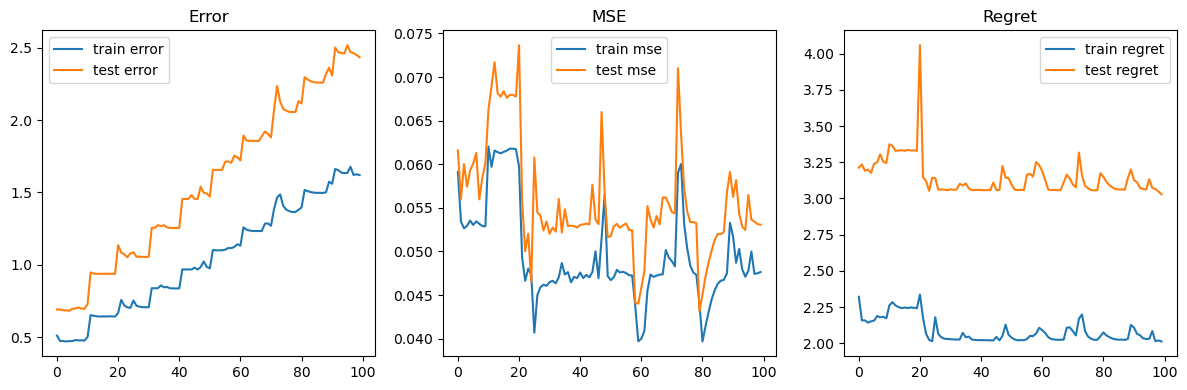

In [236]:
state_dicts_cvx, best_cvx = trainer.fit()

In [237]:
lstm_opt.load_state_dict(state_dicts_cvx[-1])

<All keys matched successfully>

In [238]:
lstm_opt_transfer.load_state_dict(lstm.state_dict())

<All keys matched successfully>

Step 0:
Average train loss: 0.4589 | Average test loss: 0.7162

Step 0:
Average train regret: 0.4589 | Average test regret: 3.5276
Average train MSE: 0.0106 | Average test MSE: 0.0133

MSE: 0.80 | Regret: 0.20
Step 5:
Average train loss: 0.4361 | Average test loss: 0.6864
Step 10:
Average train loss: 0.4255 | Average test loss: 0.6631

Step 10:
Average train regret: 0.4255 | Average test regret: 3.2357
Average train MSE: 0.0189 | Average test MSE: 0.0200

MSE: 0.73 | Regret: 0.27
Step 15:
Average train loss: 0.5455 | Average test loss: 0.8469
Step 20:
Average train loss: 0.5324 | Average test loss: 0.8181

Step 20:
Average train regret: 0.5324 | Average test regret: 2.9723
Average train MSE: 0.0328 | Average test MSE: 0.0347

MSE: 0.67 | Regret: 0.33
Step 25:
Average train loss: 0.6428 | Average test loss: 0.9983
Step 30:
Average train loss: 0.6427 | Average test loss: 0.9807

Step 30:
Average train regret: 0.6427 | Average test regret: 2.8504
Average train MSE: 0.0423 | Average test M

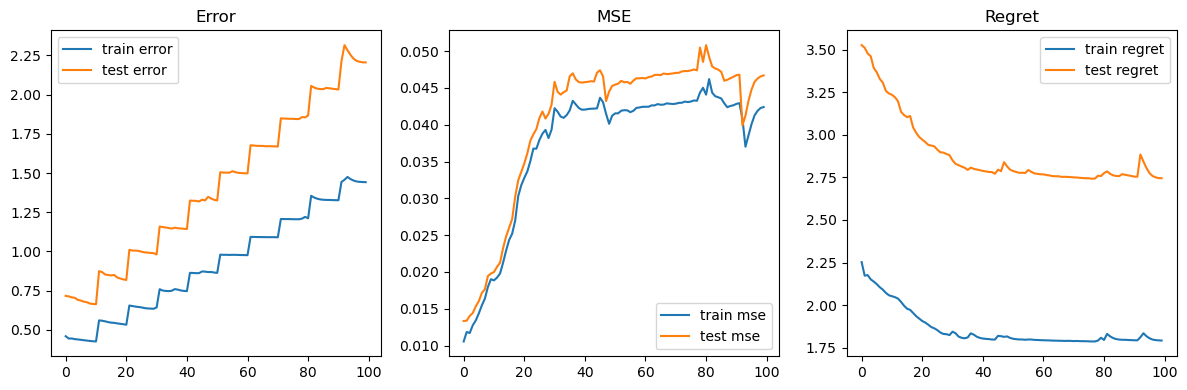

In [239]:
state_dicts_transfer, best_transfer = trainer_transfer.fit()

In [240]:
lstm_opt_transfer.load_state_dict(state_dicts_transfer[best_transfer])

<All keys matched successfully>

Evaluation

In [ ]:
pv_lstm = lstm(X_test_base.to(device))

pv_sol, _ = lstm_opt(X_test[:,:,0].unsqueeze(-1).to(device), 
                     X_test[:,:,1].to(device), 
                     X_test[:,:,2].to(device), 
                     X_test[:,:,3].to(device), 
                     torch.full([X_test.shape[0]],battery_capacity*0.5).to(device))

pv_sol_transfer, _ = lstm_opt_transfer(X_test[:,:,0].unsqueeze(-1).to(device), 
                                       X_test[:,:,1].to(device), 
                                       X_test[:,:,2].to(device), 
                                       X_test[:,:,3].to(device), 
                                       torch.full([X_test.shape[0]],battery_capacity*0.5).to(device))


In [ ]:
cvx_solutions = []
cvx_real_solutions = []
cvx_transfer_solutions = []
cvx_transfer_real_solutions = []
lstm_solutions = []
lstm_real_solutions = []
naive_solutions = []
naive_real_solutions = []
opt_solutions = []

for i in range(len(X_test)):   
    # CVX forecast
    pv.value = torch_py(rescale(pv_sol[i], scalers_opt[0]))
    load.value = torch_py(X_test[i,:,1])
    off.value = torch_py(X_test[i,:,2])
    inj.value = torch_py(X_test[i,:,3])
    initial_battery_energy.value = battery_capacity * 0.5
    cvx_solutions.append(problem.solve())

    # CVX real
    pv_fcst.value = torch_py(rescale(y_test[i,:,0], scalers_normal[0]))
    load_fcst.value = torch_py(X_test[i,:,1])
    off_fcst.value = torch_py(X_test[i,:,2])
    inj_fcst.value = torch_py(X_test[i,:,3])
    initial_battery_energy_fcst.value = battery_capacity * 0.5
    bat_charge_fcst.value = bat_charge.value
    bat_discharge_fcst.value = bat_discharge.value    
    cvx_real_solutions.append(problem_fcst.solve())
    
    # CVX Transfer forecast
    pv.value = torch_py(rescale(pv_sol_transfer[i], scalers_opt[0]))
    load.value = torch_py(X_test[i,:,1])
    off.value = torch_py(X_test[i,:,2])
    inj.value = torch_py(X_test[i,:,3])
    initial_battery_energy.value = battery_capacity * 0.5
    cvx_transfer_solutions.append(problem.solve())
    
    # CVX Transfer real
    pv_fcst.value = torch_py(rescale(y_test[i,:,0], scalers_normal[0]))
    load_fcst.value = torch_py(X_test[i,:,1])
    off_fcst.value = torch_py(X_test[i,:,2])
    inj_fcst.value = torch_py(X_test[i,:,3])
    initial_battery_energy_fcst.value = battery_capacity * 0.5
    bat_charge_fcst.value = bat_charge.value
    bat_discharge_fcst.value = bat_discharge.value    
    cvx_transfer_real_solutions.append(problem_fcst.solve())
    
    # LSTM forecast
    pv.value = torch_py(rescale(pv_lstm[i], scalers[0]))
    load.value = torch_py(X_test[i,:,1])
    off.value = torch_py(X_test[i,:,2])
    inj.value = torch_py(X_test[i,:,3])
    initial_battery_energy.value = battery_capacity * 0.5
    lstm_solutions.append(problem.solve())

    # LSTM real
    pv_fcst.value = torch_py(rescale(y_test_base[i], scalers[0]))
    load_fcst.value = torch_py(X_test[i,:,1])
    off_fcst.value = torch_py(X_test[i,:,2])
    inj_fcst.value = torch_py(X_test[i,:,3])
    initial_battery_energy_fcst.value = battery_capacity * 0.5
    bat_charge_fcst.value = bat_charge.value
    bat_discharge_fcst.value = bat_discharge.value    
    lstm_real_solutions.append(problem_fcst.solve())
   
    # Naive forecast 
    pv.value = torch_py(rescale(X_test[i,:,0], scalers_opt[0]))
    load.value = torch_py(X_test[i,:,1])
    off.value = torch_py(X_test[i,:,2])
    inj.value = torch_py(X_test[i,:,3])
    initial_battery_energy.value = battery_capacity * 0.5
    naive_solutions.append(problem.solve())

    # Naive real
    pv_fcst.value = torch_py(rescale(y_test[i,:,0], scalers_normal[0]))
    load_fcst.value = torch_py(X_test[i,:,1])
    off_fcst.value = torch_py(X_test[i,:,2])
    inj_fcst.value = torch_py(X_test[i,:,3])
    initial_battery_energy_fcst.value = battery_capacity * 0.5
    bat_charge_fcst.value = bat_charge.value
    bat_discharge_fcst.value = bat_discharge.value    
    naive_real_solutions.append(problem_fcst.solve())
    
    # Perfect forecast
    pv.value = torch_py(rescale(y_test[i,:,0], scalers_normal[0]))
    load.value = torch_py(X_test[i,:,1])
    off.value = torch_py(X_test[i,:,2])
    inj.value = torch_py(X_test[i,:,3])
    initial_battery_energy.value = battery_capacity * 0.5
    opt_solutions.append(problem.solve())

In [ ]:
rmse_cvx = fm.rmse(torch_py(pv_sol), torch_py(y_test[:,:,0]))
rmse_cvx_transfer = fm.rmse(torch_py(pv_sol_transfer), torch_py(y_test[:,:,0]))
rmse_lstm = fm.rmse(torch_py(pv_lstm), torch_py(y_test_base))
rmse_naive = fm.rmse(torch_py(X_test_base[:,:,0]), torch_py(y_test_base))

In [ ]:
print(f"What LSTM-CVX predicted: {sum(cvx_solutions):.2f}\n"
      f"What we actually paid with LSTM-CVX: {sum(cvx_real_solutions):.2f}\n\n"
      f"What LSTM-CVX-Transfer predicted: {sum(cvx_transfer_solutions):.2f}\n"
      f"What we actually paid with LSTM-CVX-Transfer: {sum(cvx_transfer_real_solutions):.2f}\n\n"
      f"What LSTM predicted: {sum(lstm_solutions):.2f}\n"
      f"What we actually paid with LSTM: {sum(lstm_real_solutions):.2f}\n\n"
      f"What Naive predicted: {sum(naive_solutions):.2f}\n"
      f"What we actually paid with Naive: {sum(naive_real_solutions):.2f}\n\n"
      f"The optimal solution: {sum(opt_solutions):.2f}\n"
      f"What we pay with no battery: {sum(nl_data['cost']):.2f}")

In [ ]:
print(f"The CVX RMSE: {rmse_cvx:.4f}\n"
      f"The CVX transfer RMSE: {rmse_cvx_transfer:.4f}\n"
      f"The LSTM RMSE: {rmse_lstm:.4f}\nThe Naive RMSE: {rmse_naive:.4f}")

In [ ]:
lstm_cvx_metrics = [sum(cvx_solutions), sum(cvx_real_solutions), rmse_cvx, len(state_dicts_cvx), best_cvx]
#lstm_cvx_transfer_metrics = [sum(cvx_transfer_solutions), sum(cvx_transfer_real_solutions), rmse_cvx_transfer, len(state_dicts_transfer), best_transfer]
lstm_metrics = [sum(lstm_solutions), sum(lstm_real_solutions), rmse_lstm, len(state_dicts_lstm), best_lstm]
naive_metrics = [sum(naive_solutions), sum(naive_real_solutions), rmse_naive, 0, 0]
optimal_metrics = [sum(nl_data['cost']), sum(opt_solutions), 0, 0, 0]

In [ ]:
column_names = ['Solution', 'Real', 'RMSE', 'epochs', 'best']
all_metrics = pd.DataFrame([lstm_cvx_metrics, 
                            #lstm_cvx_transfer_metrics, 
                            lstm_metrics, naive_metrics, optimal_metrics],
                           columns=column_names, 
                           index=['CVX', 'CVX Transfer', 'LSTM', 'Naive', 'Perfect'])


In [ ]:
all_metrics

In [ ]:
all_metrics.to_csv('../results/building_' + str(building) + '.csv')